# PyKEEN KGE Benchmark Case Study

This notebook compares three knowledge graph embedding models in the same controlled PyKEEN setup:

- `TransE`
- `PairRE`
- `DistMult`

The goal is to keep the dataset split and evaluation protocol fixed, then compare model quality and efficiency using:

- Mean Reciprocal Rank (`MRR`)
- `Hits@1`, `Hits@3`, `Hits@10`
- training time
- parameter count

The setup is intentionally simple and reproducible, like a compact student benchmark rather than a full hyperparameter search.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from benchmark_case_study import (
    BATCH_SIZE,
    DATASET_NAME,
    EMBEDDING_DIM,
    LEARNING_RATE,
    MODEL_CONFIGS,
    NUM_EPOCHS,
    RANDOM_SEED,
    run_case_study,
    save_case_study_artifacts,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Controlled setup

All models use the same:

- dataset and predefined split
- random seed
- embedding dimension
- optimizer and learning rate
- number of epochs
- filtered rank-based evaluation on the test split

This means differences in the final metrics should mainly come from the model choice, not from changing the protocol between runs.


In [2]:
setup = pd.DataFrame(
    [
        ('Dataset', DATASET_NAME),
        ('Models', ', '.join(config['model'] for config in MODEL_CONFIGS)),
        ('Random seed', RANDOM_SEED),
        ('Embedding dimension', EMBEDDING_DIM),
        ('Epochs', NUM_EPOCHS),
        ('Batch size', BATCH_SIZE),
        ('Learning rate', LEARNING_RATE),
        ('Evaluation', 'Filtered ranking metrics on fixed test split'),
    ],
    columns=['Setting', 'Value'],
)
setup

,Setting,Value
0,Dataset,Nations
1,Models,"TransE, PairRE, DistMult"
2,Random seed,42
3,Embedding dimension,64
4,Epochs,30
5,Batch size,256
6,Learning rate,0.001
7,Evaluation,Filtered ranking metrics on fixed test split


## Run benchmark

The benchmark function trains each model on the built-in `Nations` dataset and saves the results to `results/` so they can be reused outside the notebook.


In [3]:
results, losses, dataset_info = run_case_study()
save_case_study_artifacts(results, losses, dataset_info)

pd.DataFrame([dataset_info])

,dataset,training_triples,validation_triples,testing_triples,entities,relations
0,Nations,1592,199,201,14,55


In [4]:
results_rounded = results.copy()
for column in ['train_seconds', 'mrr', 'hits@1', 'hits@3', 'hits@10']:
    results_rounded[column] = results_rounded[column].round(4)
results_rounded

,model,train_seconds,parameter_count,mrr,hits@1,hits@3,hits@10
0,PairRE,2.9347,7936,0.6447,0.4627,0.7711,0.9876
1,DistMult,2.5517,4416,0.4776,0.2836,0.5622,0.9552
2,TransE,2.3812,4416,0.3232,0.0000,0.5498,0.9826


## Quality comparison

MRR is the main ranking metric here, while Hits@k shows how often the correct entity appears near the top of the ranked list.


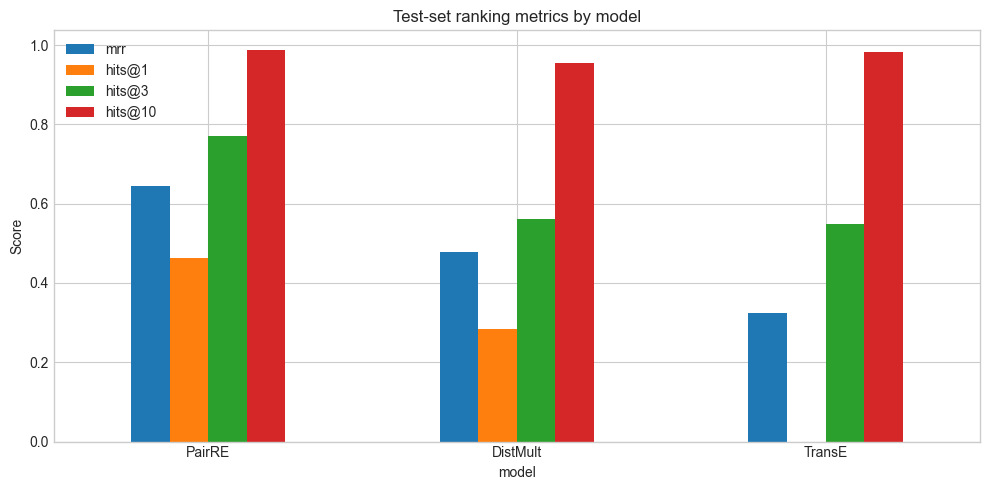

In [5]:
metric_columns = ['mrr', 'hits@1', 'hits@3', 'hits@10']
ax = results.set_index('model')[metric_columns].plot(
    kind='bar',
    figsize=(10, 5),
    rot=0,
    title='Test-set ranking metrics by model',
)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## Efficiency comparison

The assignment also asks for efficiency-quality trade-offs, so the notebook compares both training time and parameter count.


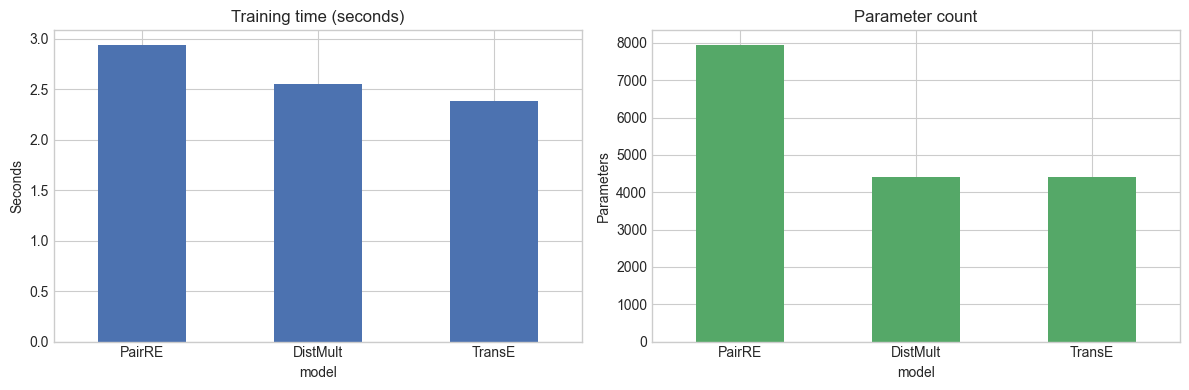

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results.plot(
    x='model',
    y='train_seconds',
    kind='bar',
    legend=False,
    ax=axes[0],
    color='#4C72B0',
    rot=0,
    title='Training time (seconds)',
)
axes[0].set_ylabel('Seconds')

results.plot(
    x='model',
    y='parameter_count',
    kind='bar',
    legend=False,
    ax=axes[1],
    color='#55A868',
    rot=0,
    title='Parameter count',
)
axes[1].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

## Training curves

A simple loss curve check helps confirm that all models trained normally under the same epoch budget.


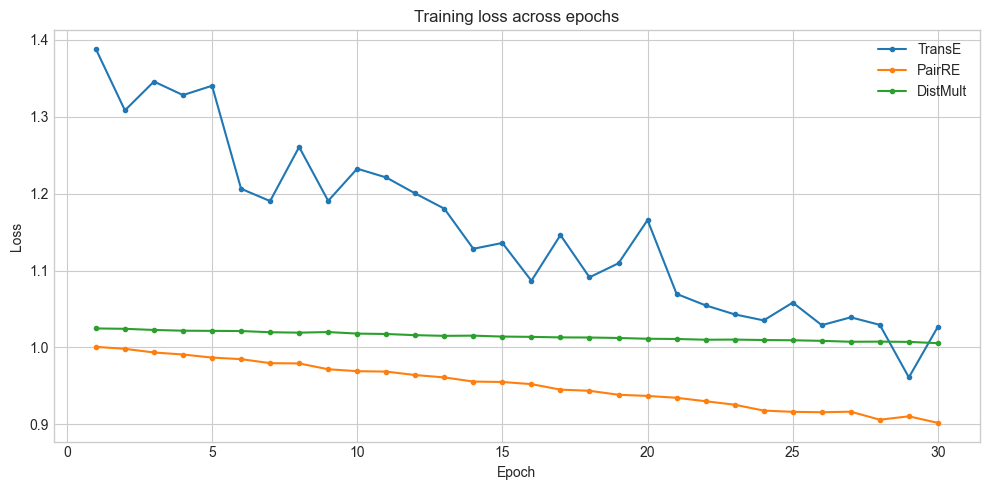

In [7]:
plt.figure(figsize=(10, 5))
for model_name, loss_values in losses.items():
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, marker='o', markersize=3, label=model_name)

plt.title('Training loss across epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Model selection rationale

The best model is selected mainly by MRR, then discussed together with parameter count and training time.


In [8]:
best = results.iloc[0]
fastest = results.loc[results['train_seconds'].idxmin()]
smallest = results.loc[results['parameter_count'].idxmin()]

baseline_params = int(smallest['parameter_count'])
extra_params = int(best['parameter_count'] - baseline_params)
extra_params_pct = 0.0 if baseline_params == 0 else 100 * extra_params / baseline_params

recommendation = f"""
### Recommendation

`{best['model']}` is the best overall choice in this benchmark.

- It achieved the highest **MRR** ({best['mrr']:.4f}).
- It also had the strongest **Hits@1** ({best['hits@1']:.4f}) and **Hits@3** ({best['hits@3']:.4f}).
- Its training time was **{best['train_seconds']:.2f} seconds**, which is very close to the fastest model in this small experiment (`{fastest['model']}` at {fastest['train_seconds']:.2f} seconds).
- The trade-off is model size: `{best['model']}` uses **{int(best['parameter_count'])} parameters**, which is {extra_params_pct:.1f}% more than the smallest models.

### Short discussion

- `PairRE` gives the best predictive quality, so it is the strongest final recommendation if accuracy matters most.
- `DistMult` is a reasonable efficiency baseline because it uses fewer parameters while still performing clearly better than `TransE` on MRR.
- `TransE` is the simplest conceptually, but in this fixed setup it was the weakest model by MRR.

For this case study, I would select **`{best['model']}`** as the final model because it gives the best ranking quality with only a moderate increase in parameter count and almost no extra training time on the `Nations` dataset.
"""

display(Markdown(recommendation))


### Recommendation

`PairRE` is the best overall choice in this benchmark.

- It achieved the highest **MRR** (0.6447).
- It also had the strongest **Hits@1** (0.4627) and **Hits@3** (0.7711).
- Its training time was **2.93 seconds**, which is very close to the fastest model in this small experiment (`TransE` at 2.38 seconds).
- The trade-off is model size: `PairRE` uses **7936 parameters**, which is 79.7% more than the smallest models.

### Short discussion

- `PairRE` gives the best predictive quality, so it is the strongest final recommendation if accuracy matters most.
- `DistMult` is a reasonable efficiency baseline because it uses fewer parameters while still performing clearly better than `TransE` on MRR.
- `TransE` is the simplest conceptually, but in this fixed setup it was the weakest model by MRR.

For this case study, I would select **`PairRE`** as the final model because it gives the best ranking quality with only a moderate increase in parameter count and almost no extra training time on the `Nations` dataset.


## Conclusion

This notebook satisfies the required case study elements:

- fixed data split and evaluation protocol
- comparison of multiple KGE models in PyKEEN
- reporting of `MRR` and `Hits@k`
- comparison of training time and parameter count
- a simple, explicit model selection rationale

A natural extension would be to repeat the same protocol on a larger dataset or with a second random seed, but that is optional for this minimal benchmark.
